<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/MNE_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
!pip install mne
import mne
import os
import sys
import pickle
import numpy as np
import pandas as pd
import glob
import importlib

import helper

#Check if we are in colab.
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

#Load the correct base path depending on if we are in colab or not.
if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks/MNE/mne_data'
else:
    base_path = os.path.join(os.getcwd(), 'mne-data', 'MNE-sample-data')

#Open pickle file and load it into 'blocking'
with open('/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/blocking.pkl', 'rb') as f:
    blocking = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Opening raw data file /content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 7000 ... 225999 =      7.000 ...   225.999 secs
Ready.
Reading 0 ... 218999  =      0.000 ...   218.999 secs...


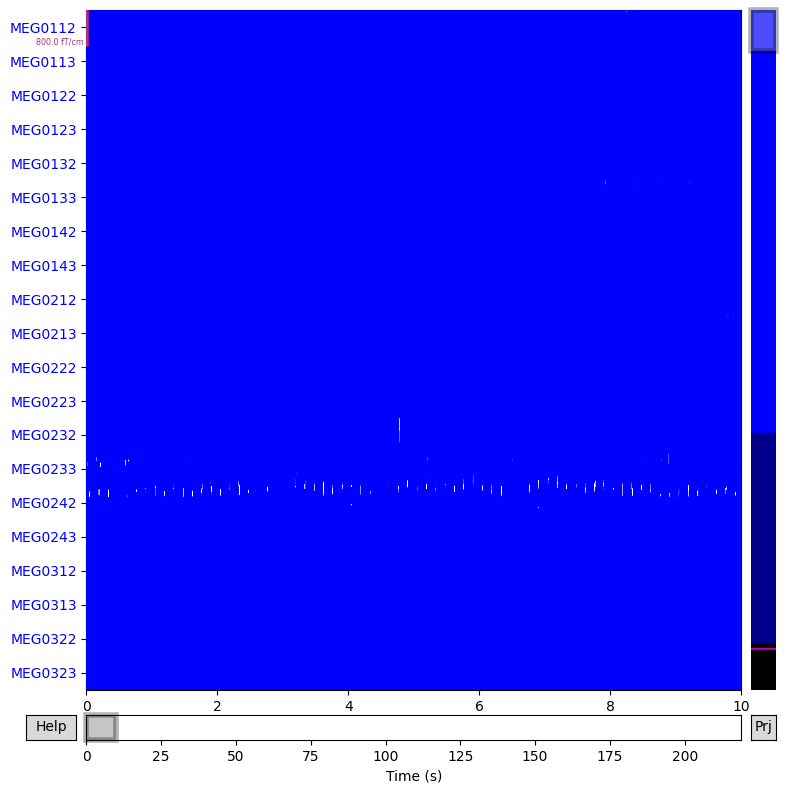

<Info | 26 non-empty values
 acq_pars: ACQactiveGround 1 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: []
 ch_names: EOG001, EOG002, ECG003, MEG0111, MEG0112, MEG0113, MEG0121, ...
 chs: 2 EOG, 1 ECG, 102 Magnetometers, 204 Gradiometers, 17 Stimulus, 2 System status channel information (Triux systems)
 custom_ref_applied: False
 description: TRIUX system at SFU
 dev_head_t: MEG device -> head transform
 device_info: 4 items (dict)
 dig: 648 items (3 Cardinal, 5 HPI, 640 Extra)
 events: 1 item (list)
 experimenter: meguser (meguser)
 gantry_angle: 68.0
 helium_info: <helium_info | he_level_raw: 50.70000076293945, meas_date: 2025-04-14 20:28:16.431264+00:00>
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 60.0
 lowpass: 330.0 Hz
 meas_date: 2025-04-14 20:44:59 UTC
 meas_id: 4 items (dict)
 nchan: 328
 proj_id: 1 item (ndarray)
 proj_name: ai
 projs: generated with dossp-2.1: off, generated with dossp-2.1: off, ..

In [77]:
#Looking at MEG .fif files and plotting them.

firstFile = '/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif'
# Load a raw MEG file
raw = mne.io.read_raw_fif(firstFile, preload=True)

# Plot the signal
raw.plot()

# View metadata
print(raw.info)

# Plot power spectral density
#raw.plot_psd()

### Get all channel names
#all_channels = raw.info['ch_names']

### Print the list of channels
#print("All channels in the file:")
#for i, ch in enumerate(all_channels):
#    print(f"{i+1:3d}: {ch}")

In [78]:
fs = 2000
### Find all STI channels
sti_channels = [ch for ch in raw.info['ch_names'] if ch.startswith('STI') or ch.startswith('STI') and ch != 'STI101']
if not sti_channels:
    raise ValueError("No STI channels found in the file")

events = mne.find_events(raw, shortest_event=1)

### Print the detected events
events = [(sp/fs, val) for sp, pre, val in events]

all_stimuli = []
count = 0
for time, val in events:
    if val >= 512:
        val -= 512
    if val >= 256:
        val -= 256
    if val == 0 or val == 60:
        continue
    if count == 0:
        all_stimuli.append([])
    all_stimuli[-1].append((time, val))
    count = (count + 1) % 3

#for item in all_stimuli:
#    v1, v2, v3 = item[0], item[1], item[2]
#    print([(v1, v2, v3, v2[0] - v1[0], v3[0] - v1[0])])

322 events found on stim channel STI101
Event IDs: [  32   33   41   42   43   72   73   82   83  256  287  297  327  337
  512  543  553  583  593 1024]


In [79]:
# Load csv, detect presence of button box
dir = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/"
files = glob.glob(dir + "M001_main_2025-04-04_*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Loaded {len(df)} trials from {len(files)} files.")

if df["key_resp.keys"].notna().sum() > df["buttonBox_2.keys"].notna().sum():
    use_button = False
    print("Using keyboard response")
    response_column = "key_resp.keys"
else:
    use_button = True
    print("Using buttonBox")
    response_column = "buttonBox_2.keys"


Loaded 675 trials from 4 files.
Using buttonBox


In [80]:
# Add correct src path BEFORE importing helper
sys.path.append('/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src')

import helper
importlib.reload(helper)

tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
all_data = helper.stimuli_load(tsv_path)

response = {}

for index, row in df.iterrows():
    stimuli = str(row["audio_file"]).replace("\\", "/")
    resp = row[response_column]

    if stimuli.lower() == "nan":
        continue

    if str(resp).lower() == "nan":
        resp = -1
    else:
        resp = int(resp)
        if not use_button:
            resp = resp - 1

    response[stimuli] = {}
    response[stimuli]["response"] = resp

for stimuli in response:
    for key in ["speaker", "sibilants", "normality", "perplexity", "tgt_word", "tgt_sound"]:
        if stimuli not in all_data:
          print("Missing:", stimuli)
          print("Closest matches:", [k for k in all_data if row['audio_file'] in k])
          continue  # Skip this row
        response[stimuli][key] = all_data[stimuli][key]


    if "bot" in response[stimuli]["speaker"]:
        response[stimuli]["speaker"] = "bot"
    else:
        response[stimuli]["speaker"] = "human"

    if response[stimuli]["sibilants"] == "nonsibilant":
        sound_pair = ["f", "θ"]
    else:
        sound_pair = ["s", "ʃ"]

    resp = response[stimuli]["response"]
    if resp == -1:
        response[stimuli]["resp_correct"] = None
    elif response[stimuli]["tgt_sound"] == sound_pair[resp]:
        response[stimuli]["resp_correct"] = True
    else:
        response[stimuli]["resp_correct"] = False

In [81]:
from collections import Counter

# Collect unmatched stimuli
unmatched = []

for stim in response:
    if stim not in all_data:
        unmatched.append(stim)

# Show summary and a preview
print(f"\n🚨 Unmatched stimuli: {len(unmatched)}")
if unmatched:
    print("Here are a few examples:")
    for stim in unmatched[:10]:
        print(" -", stim)


# -------------------------------------
# Filter: Only valid, annotated trials
# -------------------------------------
cleaned_response = {}

for stim, data in response.items():
    if stim not in all_data:
        continue  # skip if not in master stimuli list
    if "normality" not in data or "resp_correct" not in data:
        continue  # skip incomplete data
    cleaned_response[stim] = data

r = cleaned_response

# -------------------------------------
# Quick sanity check
# -------------------------------------
print(f"📊 Total entries in response: {len(response)}")
print(f"✅ Valid/filtered entries: {len(r)}\n")

# Optional peek at sample
for i, (k, v) in enumerate(r.items()):
    print(f"{k}: {v}")
    if i >= 4:
        break

# -------------------------------------
# Filtering logic
# -------------------------------------
def eval(i, cond):
    if "nor" in cond and i["normality"] != "normal":
        return False
    if "abn" in cond and i["normality"] != "abnormal":
        return False
    if "sib" in cond and i["sibilants"] != "sibilant":
        return False
    if "nos" in cond and i["sibilants"] != "nonsibilant":
        return False
    if "man" in cond and i["speaker"] != "human":
        return False
    if "bot" in cond and i["speaker"] != "bot":
        return False
    if "cor" in cond and i["resp_correct"] is not True:
        return False
    if "err" in cond and i["resp_correct"] is not False:
        return False
    return True

def count(r, cond=[]):
    return sum(1 for v in r.values() if eval(v, cond))

def rate(r, cond=[]):
    num = count(r, ["cor"] + cond)
    denom = count(r, cond)
    if denom == 0:
        print(f"[⚠️] No trials matched condition: {cond}")
        return 0.0
    return num / denom * 100

# -------------------------------------
# Breakdown
# -------------------------------------
print("📊 Normality distribution:")
print(Counter([v["normality"] for v in r.values()]))
print()

print("🧠 Total valid trials:", len(r))
print(f"✅ Overall recall: {rate(r, []):.2f}%")

def show_rate(label, cond):
    print(f"{label:<30} {rate(r, cond):>6.2f}%")

print("\n▶️ Condition breakdown:")
show_rate("Normal trials", ["nor"])
show_rate("Abnormal trials", ["abn"])
show_rate("Normal + Bot", ["nor", "bot"])
show_rate("Abnormal + Bot", ["abn", "bot"])
show_rate("Normal + Human", ["nor", "man"])
show_rate("Abnormal + Human", ["abn", "man"])

show_rate("Normal + Bot + Sibilant", ["nor", "bot", "sib"])
show_rate("Abnormal + Bot + Sibilant", ["abn", "bot", "sib"])
show_rate("Normal + Human + Sibilant", ["nor", "man", "sib"])
show_rate("Abnormal + Human + Sibilant", ["abn", "man", "sib"])

show_rate("Normal + Bot + Nonsibilant", ["nor", "bot", "nos"])
show_rate("Abnormal + Bot + Nonsibilant", ["abn", "bot", "nos"])
show_rate("Normal + Human + Nonsibilant", ["nor", "man", "nos"])
show_rate("Abnormal + Human + Nonsibilant", ["abn", "man", "nos"])



🚨 Unmatched stimuli: 0
📊 Total entries in response: 656
✅ Valid/filtered entries: 656

../stimuli/demo/bot2/bot2_the_half_marathon_is_my_thirst.wav: {'response': 1, 'speaker': 'bot', 'sibilants': 'nonsibilant', 'normality': 'abnormal', 'perplexity': '1856.8690450113313', 'tgt_word': 'thirst', 'tgt_sound': 'θ', 'resp_correct': True}
../stimuli/demo/F002/F002_i_just_heard_the_boss_fired_fred.wav: {'response': 0, 'speaker': 'human', 'sibilants': 'nonsibilant', 'normality': 'normal', 'perplexity': '1540.2988283879800', 'tgt_word': 'fred', 'tgt_sound': 'f', 'resp_correct': True}
../stimuli/demo/F001/F001_the_cake's_divided_into_thor.wav: {'response': 1, 'speaker': 'human', 'sibilants': 'nonsibilant', 'normality': 'abnormal', 'perplexity': '1090.9658704570900', 'tgt_word': 'thor', 'tgt_sound': 'θ', 'resp_correct': True}
../stimuli/demo/bot2/bot2_you_sew_with_needle_and_thread.wav: {'response': 1, 'speaker': 'bot', 'sibilants': 'nonsibilant', 'normality': 'normal', 'perplexity': '145.2525023

In [82]:
#TODO::: Let's do recall calculations for M002 and M003.
#TODO::: Get .csv files for those experiments from Jetic.

In [83]:
import os
import helper

# Flatten the blocking.pkl file
print(f"Total blocks: {len(blocking)}")
print(f"First block (sample): {blocking[0][:5]}")

stimulus_order = []
for block in blocking:
    for entry in block:
        if isinstance(entry, list):
            stimulus_order.extend([e for e in entry if isinstance(e, str)])
        elif isinstance(entry, str):
            stimulus_order.append(entry)

print("✅ Flattened stimulus count:", len(stimulus_order))
print("👀 Sample from stimulus_order:")
for i, stim in enumerate(stimulus_order[:10]):
    print(f"{i+1:2d}: {stim}")

# Load all_data from TSVs
tsv_path = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
all_data = helper.stimuli_load(tsv_path)
print("✅ Entries in all_data:", len(all_data))

# Optional: show a few keys from all_data
print("\n📄 Sample keys in all_data:")
for i, key in enumerate(list(all_data.keys())[:10]):
    print(f"{i+1:2d}: {key}")

# Compare each entry
print("\n📊 Matched stimuli with metadata:")
missing = []

for stim in stimulus_order:
    if stim in all_data:
        meta = all_data[stim]
        print(f"{stim} → {meta['normality']}, {meta['sibilants']}, {meta['speaker']}")
    else:
        missing.append(stim)

print(f"\n❌ Unmatched entries: {len(missing)}")
if missing:
    print("🔍 Sample unmatched:")
    for m in missing[:5]:
        print(" -", m)



Total blocks: 8
First block (sample): ['../stimuli/demo/bot2/bot2_the_yellow_paintball_gun_can_suit.wav', '../stimuli/demo/bot/bot_suddenly_he_felt_a_shock.wav', '../stimuli/demo/F002/F002_the_girl_lost_her_new_blue_shoe.wav', '../stimuli/demo/bot/bot_his_gift_is_a_little_blue_shell.wav', "../stimuli/demo/F002/F002_there's_a_fluffy_brown_sock.wav"]
✅ Flattened stimulus count: 656
👀 Sample from stimulus_order:
 1: ../stimuli/demo/bot2/bot2_the_yellow_paintball_gun_can_suit.wav
 2: ../stimuli/demo/bot/bot_suddenly_he_felt_a_shock.wav
 3: ../stimuli/demo/F002/F002_the_girl_lost_her_new_blue_shoe.wav
 4: ../stimuli/demo/bot/bot_his_gift_is_a_little_blue_shell.wav
 5: ../stimuli/demo/F002/F002_there's_a_fluffy_brown_sock.wav
 6: ../stimuli/demo/F001/F001_his_promises_are_easily_said.wav
 7: ../stimuli/demo/F002/F002_she_passes_the_work_to_shoe.wav
 8: ../stimuli/demo/bot2/bot2_the_tools_are_all_in_the_old_shed.wav
 9: ../stimuli/demo/bot/bot_i_recall_what_it_had_shed.wav
10: ../stimuli/demo

In [84]:
import mne
import helper

# --- Load raw MEG file ---
fif_path = "/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif"
raw = mne.io.read_raw_fif(fif_path, preload=False)
events = mne.find_events(raw, stim_channel="STI101", shortest_event=1)

print(f"\n📦 Total events: {len(events)}\n")

# --- Show how the first few are decoded ---
print("🔍 Preview decoded events:")
for i, e in enumerate(events[:10]):
    decoded = helper.trigger_decode(e[2])
    print(f"{i+1:2d}: Trigger ID={e[2]:>3} → Decoded: {decoded}")

# --- Count word_on events ---
# BEFORE fix: use "speaker" == "word_on"
# AFTER fix: use "trigger" == "word_on"

# Try both ways just to compare
word_on_by_speaker = [e for e in events if helper.trigger_decode(e[2])["speaker"] == "word_on"]
word_on_by_trigger = [e for e in events if helper.trigger_decode(e[2]).get("trigger") == "word_on"]

print(f"\n🎯 Detected word_on events (by 'speaker' == 'word_on'): {len(word_on_by_speaker)}")
print(f"🎯 Detected word_on events (by 'trigger' == 'word_on'): {len(word_on_by_trigger)}")

# Summary
if len(word_on_by_speaker) > 0 and len(word_on_by_trigger) == 0:
    print("🟡 You're using the OLD version of helper.py (abusing 'speaker')")
elif len(word_on_by_trigger) > 0 and len(word_on_by_speaker) == 0:
    print("🟢 You're using the FIXED version of helper.py (correct use of 'trigger')")
elif len(word_on_by_trigger) == 0 and len(word_on_by_speaker) == 0:
    print("❌ No word_on events detected. Either decoding logic is wrong or triggers are missing.")
else:
    print("⚠️ Both speaker/trigger returned results — something is inconsistent.")


word_on_events = [
    e for e in events if helper.trigger_decode(e[2]).get("trigger") == "word_on"
]


Opening raw data file /content/drive/MyDrive/Colab Notebooks/MNE/MNE_data/m_002/250414/M002_block0_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 7000 ... 225999 =      7.000 ...   225.999 secs
Ready.
322 events found on stim channel STI101
Event IDs: [  32   33   41   42   43   72   73   82   83  256  287  297  327  337
  512  543  553  583  5

<ipython-input-98-a5285248fdb6>:2: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events, sfreq=raw.info['sfreq'])


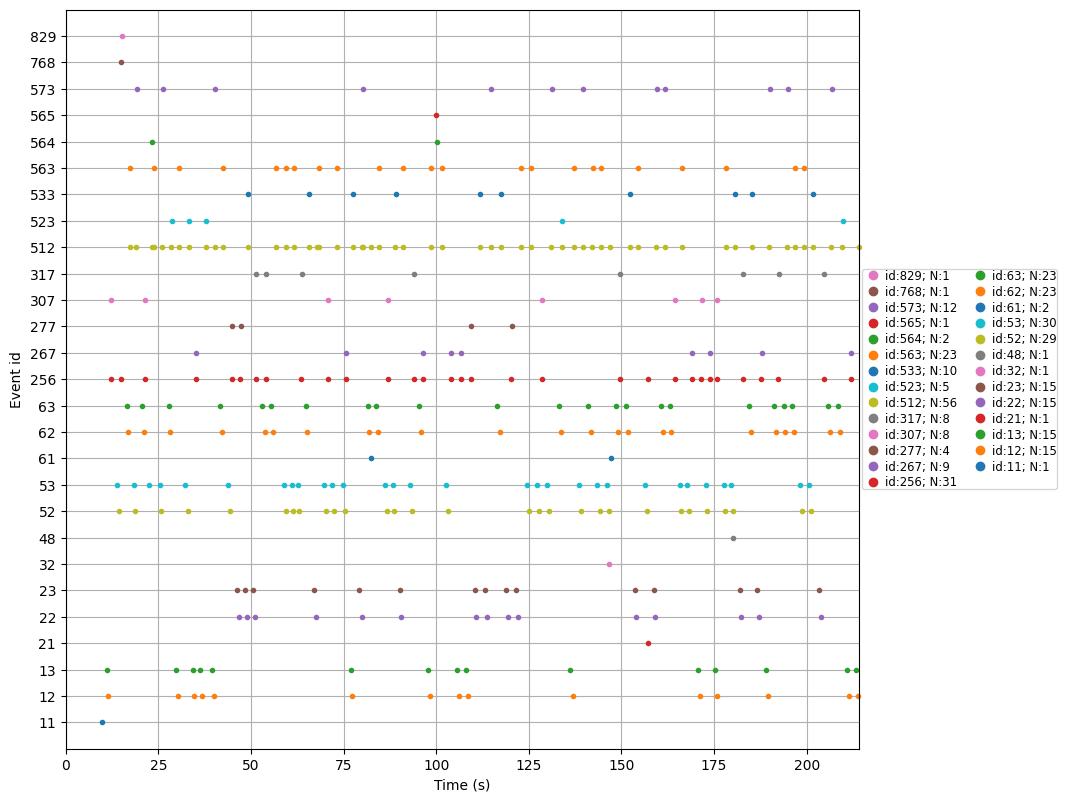

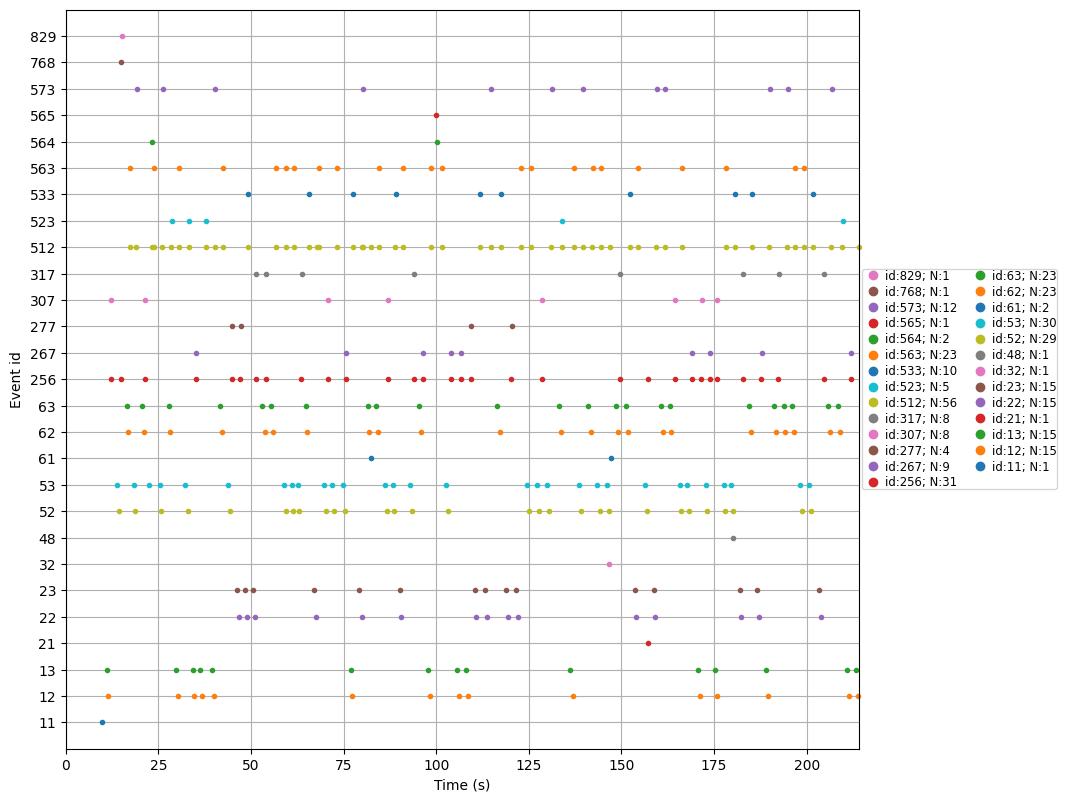

In [98]:
# Visual inspection
mne.viz.plot_events(events, sfreq=raw.info['sfreq'])

